In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn sqlalchemy pyodbc

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [84]:
df = pd.read_csv(r"C:\Users\pk706\Downloads\Churn_Modelling (1).csv")

In [85]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [86]:
df.shape

(10000, 14)

In [87]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [89]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Quality check

In [90]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(0)

### Target Distribution

In [92]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [93]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

## Data Cleaning

In [94]:
### rownumber, customerID and Surname are not useful for our churn model so we will not inlcude these.
df.drop(
    ['RowNumber', 'Surname'],
    axis=1,
    inplace=True
)

In [95]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Explorartory Data Analysis (EDA)

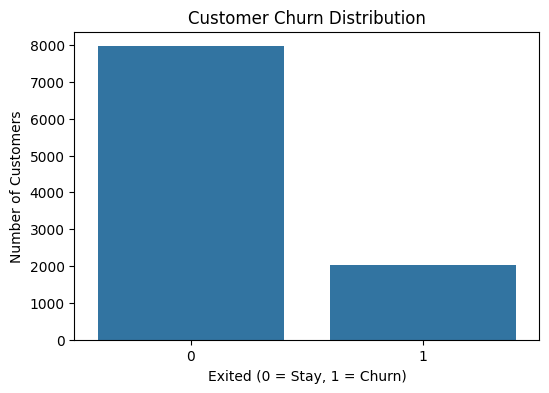

In [96]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stay, 1 = Churn)')
plt.ylabel('Number of Customers')

plt.show()

### Churn Rate

In [97]:
churn_rate = df['Exited'].mean() * 100

print(
    f"Overall Churn Rate: {churn_rate:.2f}%"
)

Overall Churn Rate: 20.37%


### Geography Analysis

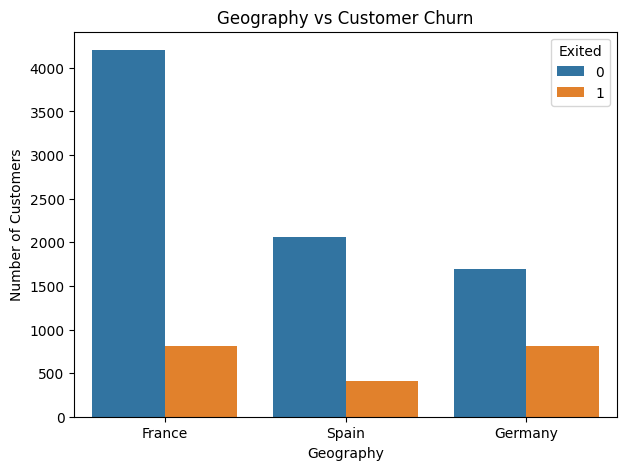

In [98]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title('Geography vs Customer Churn')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')

plt.show()

In [99]:
geography_churn = (
    df.groupby('Geography')['Exited']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(geography_churn)

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64


### Gender Analysis

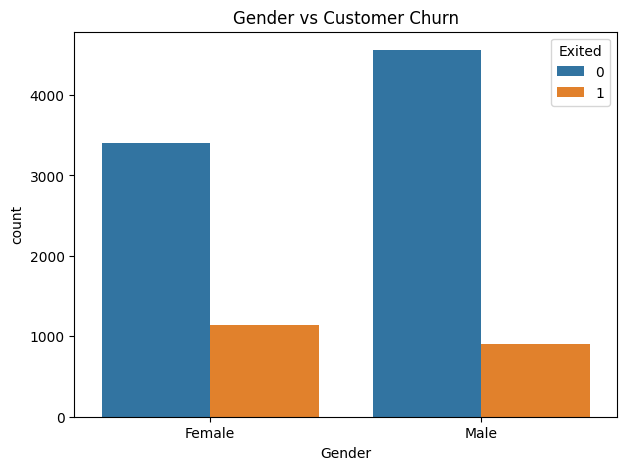

In [100]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title('Gender vs Customer Churn')

plt.show()

In [101]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=[
        '18-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

In [102]:
age_churn = (
    df.groupby(
        'AgeGroup',
        observed=True
    )['Exited']
    .mean()
    .mul(100)
)

print(age_churn)

AgeGroup
18-30     7.502569
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: Exited, dtype: float64


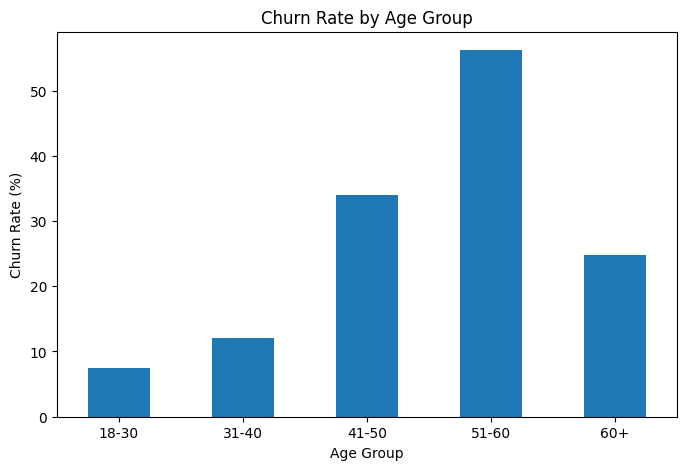

In [103]:
plt.figure(figsize=(8, 5))

age_churn.plot(kind='bar')

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.show()

## Active Membership

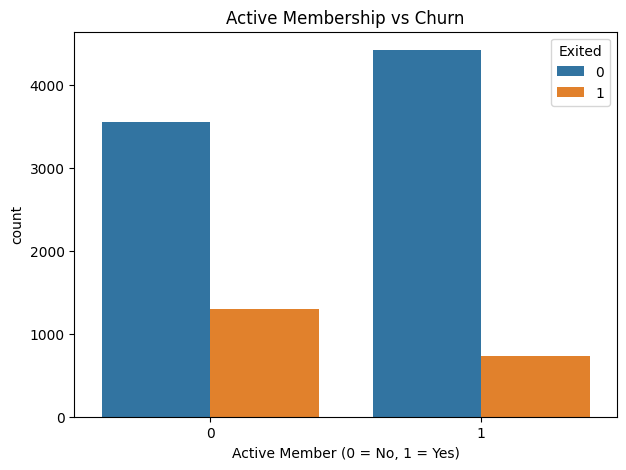

In [104]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.title('Active Membership vs Churn')
plt.xlabel('Active Member (0 = No, 1 = Yes)')

plt.show()

In [105]:
active_churn = (
    df.groupby('IsActiveMember')['Exited']
      .mean()
      .mul(100)
)

print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [106]:
product_churn = (
    df.groupby('NumOfProducts')['Exited']
      .mean()
      .mul(100)
)

print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


## Balance Analysis

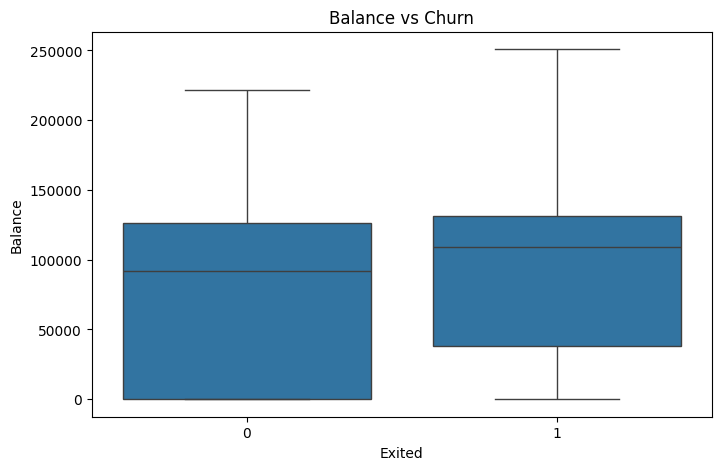

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title('Balance vs Churn')

plt.show()

## Credit Score Analysis

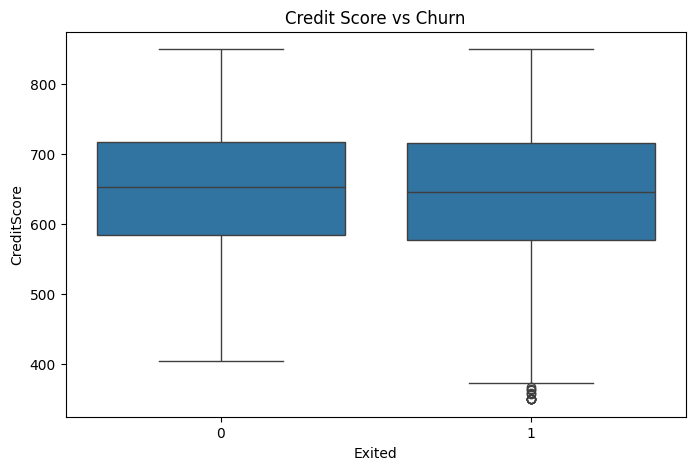

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.title('Credit Score vs Churn')

plt.show()

## Correlation Analysis

In [31]:
numeric_df = df.select_dtypes(
    include=np.number
)

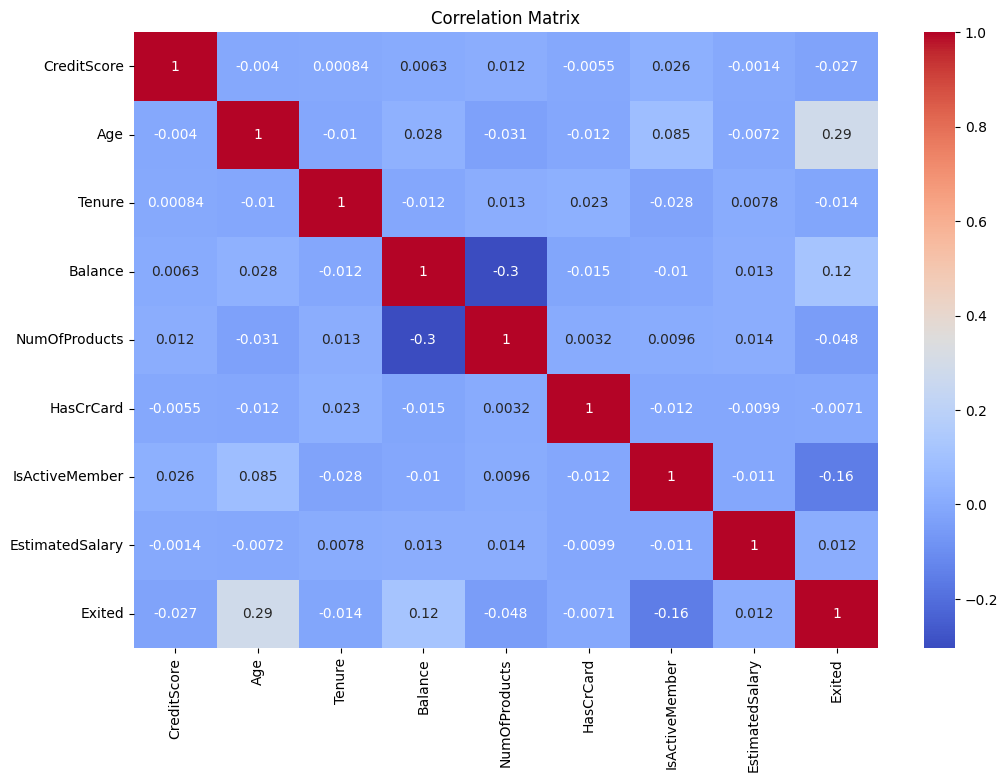

In [109]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

## preparing data for SQL

In [110]:
df_sql = df.drop(
    'AgeGroup',
    axis=1
).copy()

In [111]:
df_sql.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Pyhton SQL Server Connection

In [112]:
from sqlalchemy import create_engine

server = r'localhost\SQLEXPRESS'
database = 'BankChurnDB'

connection_string = (
    f"mssql+pyodbc://{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

## Test SQL Connection

In [36]:
with engine.connect() as connection:
    print("SQL Server connection successful!")

SQL Server connection successful!


## Send Pandas Data to SQL Server

In [113]:
df_sql.to_sql(
    'bank_customers',
    con=engine,
    if_exists='replace',
    index=False
)

82

## Verify SQL data from Jupyter

In [114]:
query = """
SELECT TOP 10 *
FROM bank_customers
"""

sql_data = pd.read_sql(
    query,
    engine
)

sql_data

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## SQL Business Analytics

In [115]:
query = """
SELECT COUNT(*) AS TotalCustomers
FROM bank_customers
"""

pd.read_sql(query, engine)

,TotalCustomers
0,10000


## Churned Customers

In [116]:
query = """
SELECT
    COUNT(*) AS ChurnedCustomers
FROM bank_customers
WHERE Exited = 1
"""

pd.read_sql(query, engine)

,ChurnedCustomers
0,2037


## Overall Churn Rate

In [117]:
query = """
SELECT
    COUNT(CASE WHEN Exited = 1 THEN 1 END) * 100.0
    / COUNT(*) AS ChurnRate
FROM bank_customers
"""

pd.read_sql(query, engine)

,ChurnRate
0,20.37


## Geography Analysis Using SQL

In [118]:
query = """
SELECT
    Geography,
    COUNT(*) AS TotalCustomers,
    SUM(Exited) AS ChurnedCustomers,
    AVG(CAST(Exited AS FLOAT)) * 100 AS ChurnRate
FROM bank_customers
GROUP BY Geography
ORDER BY ChurnRate DESC
"""

sql_geography = pd.read_sql(
    query,
    engine
)

sql_geography

,Geography,TotalCustomers,ChurnedCustomers,ChurnRate
0,Germany,2509,814,32.443204
1,Spain,2477,413,16.673395
2,France,5014,810,16.154767


## Active Members using SQL

In [119]:
query = """
SELECT
    IsActiveMember,
    COUNT(*) AS TotalCustomers,
    SUM(Exited) AS ChurnedCustomers,
    AVG(CAST(Exited AS FLOAT)) * 100 AS ChurnRate
FROM bank_customers
GROUP BY IsActiveMember
"""

sql_active = pd.read_sql(
    query,
    engine
)

sql_active

,IsActiveMember,TotalCustomers,ChurnedCustomers,ChurnRate
0,0,4849,1302,26.850897
1,1,5151,735,14.269074


## Product Analysis using SQL

In [120]:
query = """
SELECT
    NumOfProducts,
    COUNT(*) AS TotalCustomers,
    SUM(Exited) AS ChurnedCustomers,
    AVG(CAST(Exited AS FLOAT)) * 100 AS ChurnRate
FROM bank_customers
GROUP BY NumOfProducts
ORDER BY NumOfProducts
"""

sql_products = pd.read_sql(
    query,
    engine
)

sql_products

,NumOfProducts,TotalCustomers,ChurnedCustomers,ChurnRate
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


## MACHINE LEARNING

In [121]:
ml_df = df_sql.copy()

In [122]:
ml_df = ml_df.drop(
    'CustomerId',
    axis=1,
    inplace=False
)

### Encode Categorical Variables

In [123]:
ml_df = pd.get_dummies(
    ml_df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [47]:
ml_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


### separate x and y

In [48]:
X = ml_df.drop(
    'Exited',
    axis=1
)

y = ml_df['Exited']

### Train/Test Split

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Logistic Regression

In [125]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [126]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [127]:
log_pred = log_model.predict(
    X_test_scaled
)

### Logistic Regression Evaluation

In [128]:
print(
    classification_report(
        y_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [129]:
log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print(
    "Logistic Regression Accuracy:",
    round(log_accuracy, 4)
)

Logistic Regression Accuracy: 0.808


## Random Forest

In [130]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [131]:
rf_pred = rf_model.predict(
    X_test
)

## Random Forest evaluation

In [132]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [133]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

Random Forest Accuracy: 0.8615


## Confusion Matrix

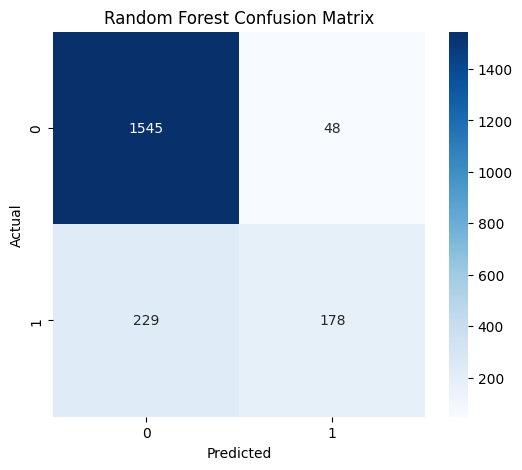

In [134]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

## ROC-AUC

In [135]:
rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

In [136]:
rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

print(
    "Random Forest ROC-AUC:",
    round(rf_auc, 4)
)

Random Forest ROC-AUC: 0.8553


## ROC Curve

In [137]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probability
)

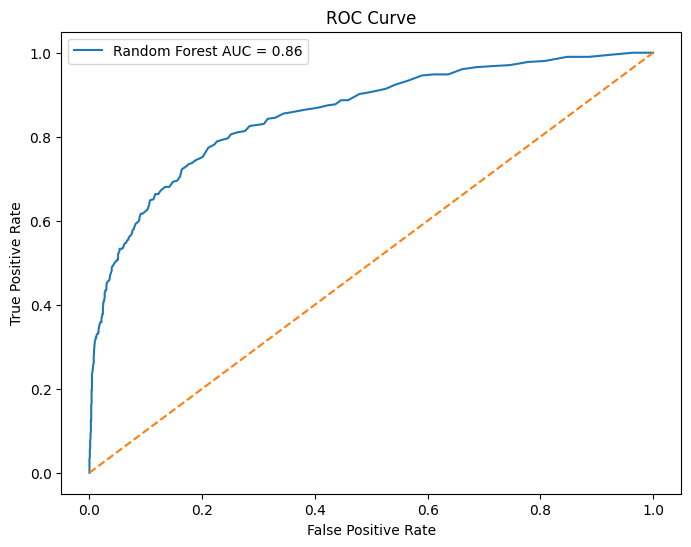

In [138]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest AUC = {rf_auc:.2f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

## Compare Models

In [139]:
log_probability = log_model.predict_proba(
    X_test_scaled
)[:, 1]

log_auc = roc_auc_score(
    y_test,
    log_probability
)

In [140]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        log_accuracy,
        rf_accuracy
    ],

    'ROC_AUC': [
        log_auc,
        rf_auc
    ]
})

model_results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.8080,0.774778
1,Random Forest,0.8615,0.855280


## Feature Importance

In [141]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [142]:
feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

feature_importance

,Feature,Importance
1,Age,0.250597
3,Balance,0.142133
7,EstimatedSalary,0.137958
0,CreditScore,0.134777
4,NumOfProducts,0.131539
2,Tenure,0.079725
6,IsActiveMember,0.036850
8,Geography_Germany,0.033374
10,Gender_Male,0.020249
5,HasCrCard,0.018294


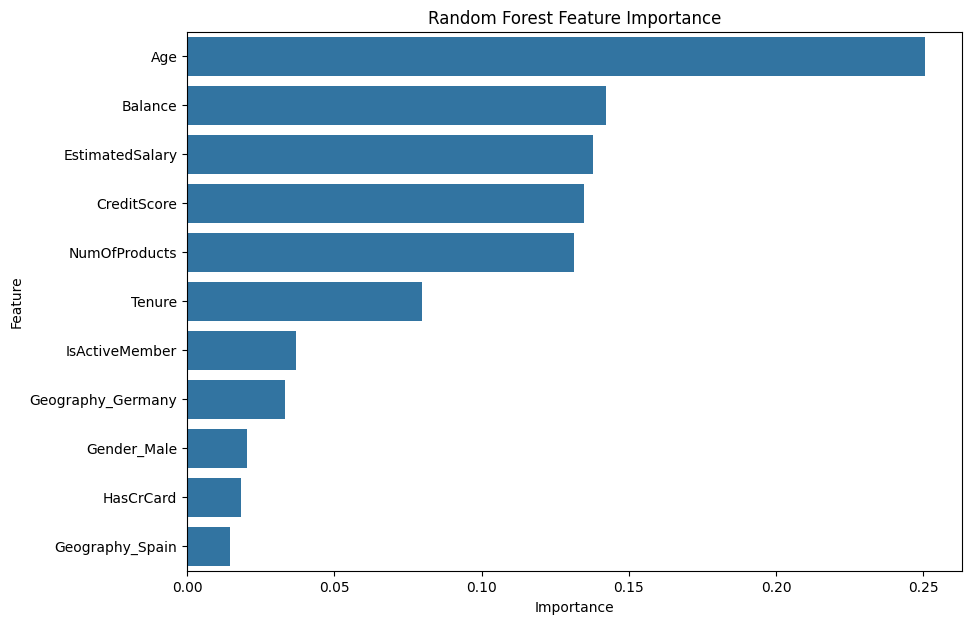

In [143]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

## Predict churn probability for customers

In [144]:
all_customer_probability = rf_model.predict_proba(
    X
)[:, 1]

In [145]:
customer_predictions = df_sql.copy()

customer_predictions[
    'ChurnProbability'
] = all_customer_probability

In [146]:
customer_predictions['RiskLevel'] = pd.cut(
    customer_predictions['ChurnProbability'],
    bins=[0, 0.30, 0.60, 1],
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)

In [147]:
customer_predictions.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ChurnProbability,RiskLevel
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.655,High Risk
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.170,Low Risk
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.955,High Risk
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.030,Low Risk
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.020,Low Risk


## High-Risk Customers

In [148]:
high_risk_customers = (
    customer_predictions[
        customer_predictions['RiskLevel'] == 'High Risk'
    ]
    .sort_values(
        'ChurnProbability',
        ascending=False
    )
)

In [149]:
high_risk_customers.head(20)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ChurnProbability,RiskLevel
8923,15570002,625,Germany,Female,55,8,118772.71,4,0,0,135853.62,1,1.000,High Risk
6911,15710087,705,Germany,Female,54,3,125889.30,3,1,0,96013.50,1,1.000,High Risk
1657,15752342,704,Germany,Female,54,6,133656.91,3,1,0,145071.33,1,0.995,High Risk
9438,15641175,701,Germany,Male,63,3,120916.52,3,0,0,144727.45,1,0.990,High Risk
8755,15697510,707,Spain,Female,52,7,0.00,1,1,0,109688.82,1,0.990,High Risk
4114,15647008,624,Germany,Male,54,3,116726.22,1,1,0,110498.10,1,0.990,High Risk
6058,15684868,668,Germany,Male,56,9,110993.79,1,1,0,134396.64,1,0.990,High Risk
3246,15579212,638,France,Male,57,6,0.00,1,1,0,33676.48,1,0.985,High Risk
4054,15734762,602,France,Female,56,3,115895.22,3,1,0,4176.17,1,0.985,High Risk
3913,15732266,553,Germany,Male,53,5,127997.83,1,1,0,165378.66,1,0.985,High Risk


## Send ML predictions back to SQL

In [150]:
customer_predictions.to_sql(
    'customer_churn_predictions',
    con=engine,
    if_exists='replace',
    index=False
)

17

## Query high-risk customers from SQL

In [151]:
query = """
SELECT TOP 20
    CustomerId,
    Geography,
    Age,
    Balance,
    NumOfProducts,
    IsActiveMember,
    ChurnProbability,
    RiskLevel
FROM customer_churn_predictions
WHERE RiskLevel = 'High Risk'
ORDER BY ChurnProbability DESC
"""

high_risk_sql = pd.read_sql(
    query,
    engine
)

high_risk_sql

,CustomerId,Geography,Age,Balance,NumOfProducts,IsActiveMember,ChurnProbability,RiskLevel
0,15710087,Germany,54,125889.30,3,0,1.000,High Risk
1,15570002,Germany,55,118772.71,4,0,1.000,High Risk
2,15752342,Germany,54,133656.91,3,0,0.995,High Risk
3,15647008,Germany,54,116726.22,1,0,0.990,High Risk
4,15684868,Germany,56,110993.79,1,0,0.990,High Risk
5,15697510,Spain,52,0.00,1,0,0.990,High Risk
6,15641175,Germany,63,120916.52,3,0,0.990,High Risk
7,15813412,France,55,44020.89,1,0,0.985,High Risk
8,15640846,Germany,58,106458.31,4,0,0.985,High Risk
9,15571059,France,54,0.00,1,0,0.985,High Risk
